# Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()

,Timestamp,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Speed_kmh,Latitude,Longitude,Motion_Intensity,Crash_Label
0,2026-01-01 10:00:00,0.448357,0.083487,9.963792,-0.013569,0.056601,-0.003593,31.601007,17.384853,78.486216,9.974224,0
1,2026-01-01 10:00:01,0.130868,-0.151825,9.711793,-0.015690,-0.060578,0.070635,65.337499,17.384322,78.487744,9.713861,0
2,2026-01-01 10:00:02,0.523844,0.013813,9.426302,0.091270,-0.013817,0.010091,31.599463,17.383930,78.486613,9.440857,0
3,2026-01-01 10:00:03,0.961515,0.457366,9.561250,0.113221,-0.048402,0.024528,27.447587,17.384121,78.486100,9.620353,0
4,2026-01-01 10:00:04,0.082923,0.738928,9.802856,-0.026444,0.029465,0.055870,79.673292,17.384339,78.485709,9.831016,0


In [2]:
df.shape[0]

8000

# Data Cleaning

In [3]:
df = df.dropna()
df.shape[0]

8000

In [4]:
df = df.drop(columns = ["Timestamp", "Latitude", "Longitude"])
df.head()

,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Speed_kmh,Motion_Intensity,Crash_Label
0,0.448357,0.083487,9.963792,-0.013569,0.056601,-0.003593,31.601007,9.974224,0
1,0.130868,-0.151825,9.711793,-0.015690,-0.060578,0.070635,65.337499,9.713861,0
2,0.523844,0.013813,9.426302,0.091270,-0.013817,0.010091,31.599463,9.440857,0
3,0.961515,0.457366,9.561250,0.113221,-0.048402,0.024528,27.447587,9.620353,0
4,0.082923,0.738928,9.802856,-0.026444,0.029465,0.055870,79.673292,9.831016,0


In [5]:
df["Speed_kmh"] = df["Speed_kmh"] / 3.6
df = df.rename(columns={"Motion_Intensity": "Acceleration", "Speed_kmh": "Speed"})

df.head()

,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Speed,Acceleration,Crash_Label
0,0.448357,0.083487,9.963792,-0.013569,0.056601,-0.003593,8.778057,9.974224,0
1,0.130868,-0.151825,9.711793,-0.015690,-0.060578,0.070635,18.149305,9.713861,0
2,0.523844,0.013813,9.426302,0.091270,-0.013817,0.010091,8.777629,9.440857,0
3,0.961515,0.457366,9.561250,0.113221,-0.048402,0.024528,7.624330,9.620353,0
4,0.082923,0.738928,9.802856,-0.026444,0.029465,0.055870,22.131470,9.831016,0


# Exploratory Data Analysis

## Normal vs Accident Events Ratio

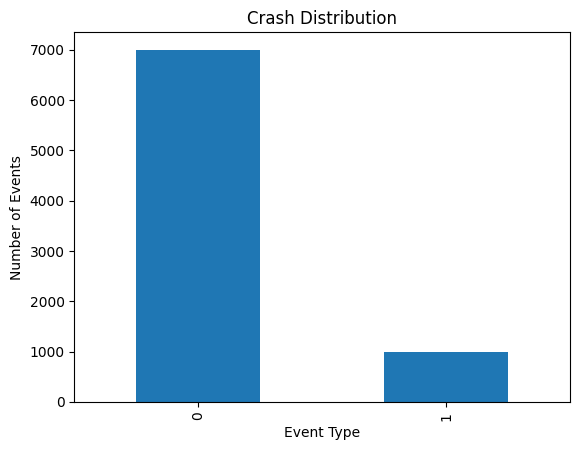

In [6]:
import matplotlib.pyplot as plt

df["Crash_Label"].value_counts().plot(kind="bar")

plt.title("Crash Distribution")
plt.ylabel("Number of Events")
plt.xlabel("Event Type")

plt.show()

## Speed Distribution in Normal vs Accident Events

### Normal Event

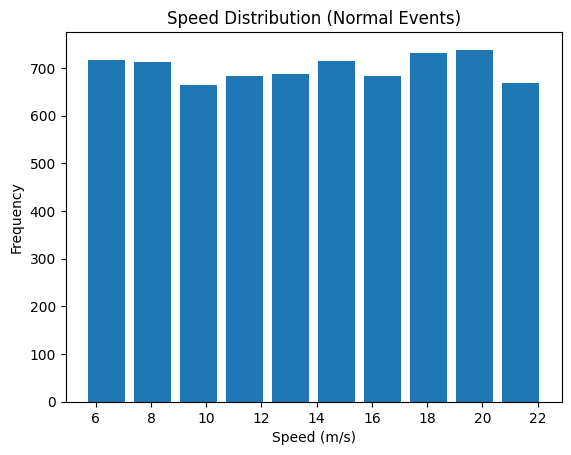

Mean: 13.902638298238797 m/s


In [7]:
normal_events = df[df["Crash_Label"] == 0]

normal_events["Speed"].plot(
    kind="hist",
    rwidth=0.8
)

plt.title("Speed Distribution (Normal Events)")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")

plt.show()

print(f"Mean:", normal_events["Speed"].mean(), "m/s")

### Accident Events

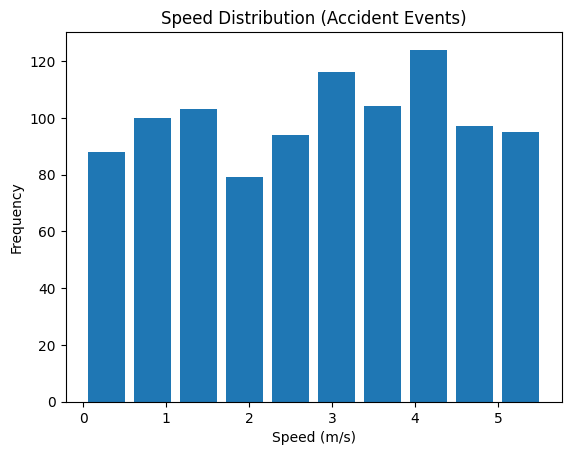

Mean: 2.8416777231649815 m/s


In [8]:
accident_events = df[df["Crash_Label"] == 1]

accident_events["Speed"].plot(
    kind="hist",
    rwidth=0.8
)

plt.title("Speed Distribution (Accident Events)")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")

plt.show()

print(f"Mean:", accident_events["Speed"].mean(), "m/s")

## Acceleration Distribution in Normal vs Accident Events

### Normal Events

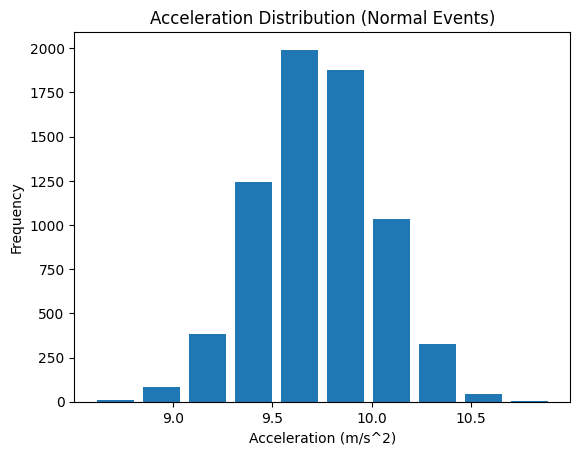

Mean: 9.729611582623736 m/s^2


In [9]:
plt.hist(
    normal_events["Acceleration"],
    rwidth=0.8
)

plt.title("Acceleration Distribution (Normal Events)")
plt.xlabel("Acceleration (m/s^2)")
plt.ylabel("Frequency")

plt.show()

print("Mean:", normal_events["Acceleration"].mean(), "m/s^2")

### Accident Events

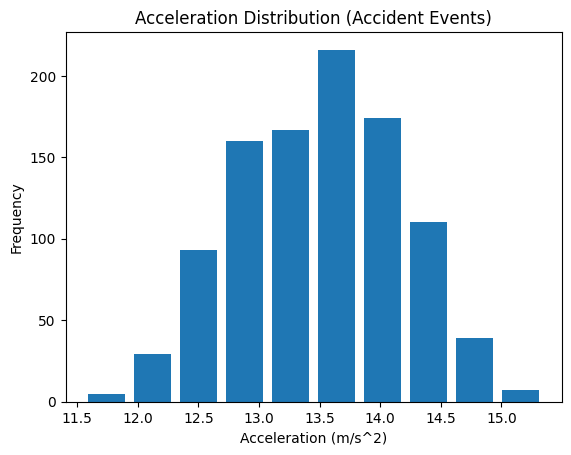

Mean: 13.493873107253341 m/s^2


In [10]:
plt.hist(
    accident_events["Acceleration"],
    rwidth=0.8
)

plt.title("Acceleration Distribution (Accident Events)")
plt.xlabel("Acceleration (m/s^2)")
plt.ylabel("Frequency")

plt.show()

print("Mean:", accident_events["Acceleration"].mean(), "m/s^2")

## Angular Speed Distribution in Normal vs Accident Events

### Normal Events

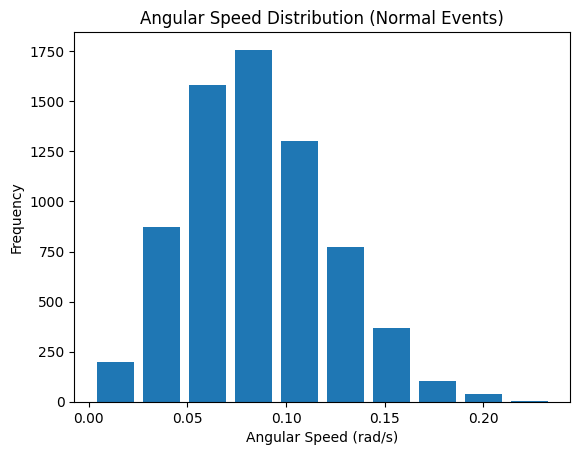

Mean: 0.08572454056782532 rad/s


In [11]:
gyro_mag_normal = (normal_events["Gyro_X"] ** 2 + normal_events["Gyro_Y"] ** 2 + normal_events["Gyro_Z"] ** 2) ** 0.5

plt.hist(
    gyro_mag_normal,
    rwidth = 0.8
)

plt.title("Angular Speed Distribution (Normal Events)")
plt.xlabel("Angular Speed (rad/s)")
plt.ylabel("Frequency")

plt.show()

print("Mean:", gyro_mag_normal.mean(), "rad/s")

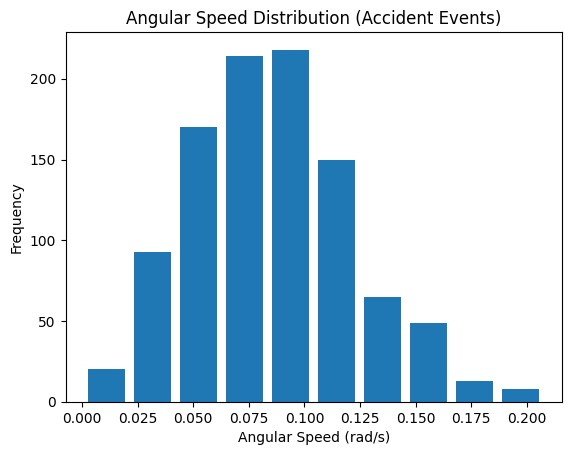

Mean: 0.08586904010871461 rad/s


In [12]:
gyro_mag_accident = (accident_events["Gyro_X"] ** 2 + accident_events["Gyro_Y"] ** 2 + accident_events["Gyro_Z"] ** 2) ** 0.5

plt.hist(
    gyro_mag_accident,
    rwidth=0.8
)

plt.title("Angular Speed Distribution (Accident Events)")
plt.xlabel("Angular Speed (rad/s)")
plt.ylabel("Frequency")

plt.show()

print("Mean:", gyro_mag_accident.mean(), "rad/s")

# Feature Engineering

In [13]:
df["Angular_Speed"] = (df["Gyro_X"] ** 2 + df["Gyro_Y"] ** 2 + df["Gyro_Z"] ** 2) ** 0.5
df.head()

,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Speed,Acceleration,Crash_Label,Angular_Speed
0,0.448357,0.083487,9.963792,-0.013569,0.056601,-0.003593,8.778057,9.974224,0,0.058315
1,0.130868,-0.151825,9.711793,-0.015690,-0.060578,0.070635,18.149305,9.713861,0,0.094367
2,0.523844,0.013813,9.426302,0.091270,-0.013817,0.010091,8.777629,9.440857,0,0.092860
3,0.961515,0.457366,9.561250,0.113221,-0.048402,0.024528,7.624330,9.620353,0,0.125552
4,0.082923,0.738928,9.802856,-0.026444,0.029465,0.055870,22.131470,9.831016,0,0.068475


# Data Scaling

In [14]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = df.drop(columns=["Crash_Label"]).to_numpy()
y = df["Crash_Label"].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model Training

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Model Metrics

In [17]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_pred, y_test) * 100} %")

Accuracy: 100.0 %


# Save Model And Scaler

In [18]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)